In [2]:
import os
import json
import shutil
from pathlib import Path
from datetime import datetime

from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# ====== PATHS ======
PROJECT_ROOT = Path.cwd().parent  # notebook is inside /notebooks
INBOX_DIR  = PROJECT_ROOT / "data" / "inbox"
RAW_DIR    = PROJECT_ROOT / "data" / "raw"
META_DIR   = PROJECT_ROOT / "data" / "metadata"
CLASS_JSON = META_DIR / "class_names.json"

REJECT_DIR = RAW_DIR / "reject"
LOG_CSV    = META_DIR / "labels_raw_log.csv"

REJECT_DIR.mkdir(parents=True, exist_ok=True)
META_DIR.mkdir(parents=True, exist_ok=True)

with open(CLASS_JSON, "r", encoding="utf-8") as f:
    class_map = json.load(f)  # keys "0".."12" -> folder names

# Ensure class folders exist
for k, folder in class_map.items():
    (RAW_DIR / folder).mkdir(parents=True, exist_ok=True)

print("CWD:", Path.cwd())
print("PROJECT_ROOT:", PROJECT_ROOT)
print("INBOX_DIR:", INBOX_DIR)
print("RAW_DIR:", RAW_DIR)
print("META_DIR:", META_DIR)



CWD: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\notebooks
PROJECT_ROOT: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification
INBOX_DIR: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\data\inbox
RAW_DIR: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\data\raw
META_DIR: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\data\metadata


In [3]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def find_images(root: Path):
    if not root.exists():
        return []
    return sorted([p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS])

def show_image_blocking(path: Path):
    """
    Forces the image to render before asking for input.
    """
    clear_output(wait=True)
    print("File:", path.name)
    print("Path:", path)

    img = Image.open(path).convert("RGB")
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()      # ensure the plot is pushed to the output cell
    plt.close()     # prevent memory buildup


print(f"Found {len(find_images(INBOX_DIR))} images in inbox.")


Found 200 images in inbox.


REJECTED -> c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\data\raw\reject\f4f7ec6332cab9c706e12fa8aaed4a6c.jpg


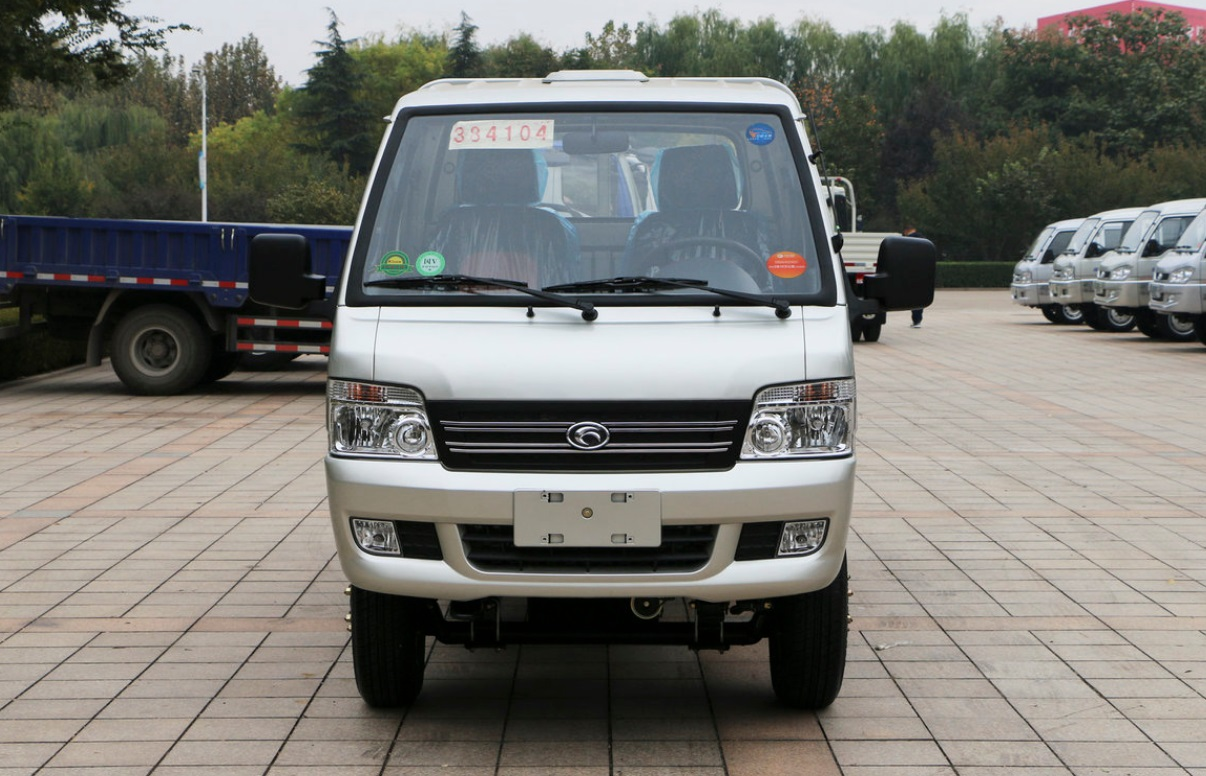

In [4]:
import csv

# human 1..13 -> internal 0..12
human_to_internal = {h: (h - 1, class_map[str(h - 1)]) for h in range(1, 14)}

def append_log(row, csv_path: Path):
    is_new = not csv_path.exists()
    with open(csv_path, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if is_new:
            writer.writeheader()
        writer.writerow(row)

def safe_move(src: Path, dst_dir: Path):
    """
    Moves image to destination. Adds suffix if file exists.
    """
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst_path = dst_dir / src.name

    if dst_path.exists():
        stem, ext = src.stem, src.suffix
        i = 1
        while True:
            candidate = dst_dir / f"{stem}_{i}{ext}"
            if not candidate.exists():
                dst_path = candidate
                break
            i += 1

    shutil.move(str(src), str(dst_path))
    return dst_path

def print_menu_1_to_13():
    print("\nChoose label (enter 1–13):")
    for h in range(1, 14):
        internal_idx, folder = human_to_internal[h]
        print(f"  {h:>2} -> {folder}")
    print("  r  -> reject")
    print("  s  -> skip (leave in inbox)")
    print("  q  -> quit")

images = find_images(INBOX_DIR)
print("Found images:", len(images))

session_id = datetime.now().strftime("%Y%m%d_%H%M%S")
i = 0

while i < len(images):
    img_path = images[i]

    # If the file was moved already, skip it
    if not img_path.exists():
        i += 1
        continue

    # Show image FIRST, then ask input
    show_image_blocking(img_path)
    print_menu_1_to_13()

    choice = input(f"[{i+1}/{len(images)}] Enter choice: ").strip().lower()

    if choice == "q":
        clear_output(wait=True)
        print("Quitting.")
        break

    if choice == "s":
        append_log({
            "session_id": session_id,
            "timestamp": datetime.now().isoformat(timespec="seconds"),
            "source_path": str(img_path),
            "action": "skip",
            "human_label": "",
            "label_index": "",
            "label_folder": "",
            "dest_path": ""
        }, LOG_CSV)
        i += 1
        continue

    if choice == "r":
        dest = safe_move(img_path, REJECT_DIR)
        clear_output(wait=True)
        print("REJECTED ->", dest)
        display(Image.open(dest).convert("RGB"))

        append_log({
            "session_id": session_id,
            "timestamp": datetime.now().isoformat(timespec="seconds"),
            "source_path": str(img_path),
            "action": "reject",
            "human_label": "",
            "label_index": "",
            "label_folder": "reject",
            "dest_path": str(dest)
        }, LOG_CSV)

        i += 1
        continue

    if choice.isdigit():
        human_label = int(choice)
        if human_label < 1 or human_label > 13:
            print("Invalid label. Enter a number from 1 to 13.")
            continue

        internal_idx, folder = human_to_internal[human_label]
        dest_dir = RAW_DIR / folder
        dest = safe_move(img_path, dest_dir)

        clear_output(wait=True)
        print(f"LABELED -> Class {human_label} ({folder})")
        print("Moved to:", dest)
        display(Image.open(dest).convert("RGB"))

        append_log({
            "session_id": session_id,
            "timestamp": datetime.now().isoformat(timespec="seconds"),
            "source_path": str(img_path),
            "action": "label",
            "human_label": human_label,
            "label_index": internal_idx,
            "label_folder": folder,
            "dest_path": str(dest)
        }, LOG_CSV)

        i += 1
        continue

    print("Invalid input. Use 1–13, r, s, or q.")


In [6]:
def count_images_in_dir(d: Path):
    return sum(1 for p in d.glob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS)

# Build an ordered list of (internal_index, folder) from the loaded class_map
# class_map keys are strings '0'..'12' so convert to int for sorting
classes = sorted([(int(k), v) for k, v in class_map.items()], key=lambda x: x[0])

print("Counts in data/raw:")
total = 0
for idx, folder in classes:
    c = count_images_in_dir(RAW_DIR / folder)
    total += c
    print(f"{folder}: {c}")
print("reject:", count_images_in_dir(REJECT_DIR))
print("total labeled copies:", total)
print("log file:", LOG_CSV)


Counts in data/raw:
class_01_motorcycle: 296
class_02_passenger_car: 987
class_03_four_tire_single_unit: 70
class_04_bus: 262
class_05_two_axle_six_tire_single_unit: 86
class_06_three_axle_single_unit: 125
class_07_four_or_more_axle_single_unit: 35
class_08_four_or_less_axle_single_trailer: 16
class_09_five_axle_tractor_semitrailer: 26
class_10_six_or_more_axle_single_trailer: 8
class_11_five_or_less_axle_multi_trailer: 4
class_12_six_axle_multi_trailer: 1
class_13_seven_or_more_axle_multi_trailer: 3
reject: 494
total labeled copies: 1919
log file: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\data\metadata\labels_raw_log.csv
